In [1]:
import pandas as pd

# Load the RTT dataset
df = pd.read_csv('data/20260228-RTT-February-2026-full-extract.csv')

# First look at the data
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
df.head()

Rows: 181233
Columns: 121


,Period,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,...,Gt 98 To 99 Weeks SUM 1,Gt 99 To 100 Weeks SUM 1,Gt 100 To 101 Weeks SUM 1,Gt 101 To 102 Weeks SUM 1,Gt 102 To 103 Weeks SUM 1,Gt 103 To 104 Weeks SUM 1,Gt 104 Weeks SUM 1,Total,Patients with unknown clock start date,Total All
0,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
1,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
2,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
3,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
4,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2


In [2]:
df.columns.tolist()

['Period',
 'Provider Parent Org Code',
 'Provider Parent Name',
 'Provider Org Code',
 'Provider Org Name',
 'Commissioner Parent Org Code',
 'Commissioner Parent Name',
 'Commissioner Org Code',
 'Commissioner Org Name',
 'RTT Part Type',
 'RTT Part Description',
 'Treatment Function Code',
 'Treatment Function Name',
 'Gt 00 To 01 Weeks SUM 1',
 'Gt 01 To 02 Weeks SUM 1',
 'Gt 02 To 03 Weeks SUM 1',
 'Gt 03 To 04 Weeks SUM 1',
 'Gt 04 To 05 Weeks SUM 1',
 'Gt 05 To 06 Weeks SUM 1',
 'Gt 06 To 07 Weeks SUM 1',
 'Gt 07 To 08 Weeks SUM 1',
 'Gt 08 To 09 Weeks SUM 1',
 'Gt 09 To 10 Weeks SUM 1',
 'Gt 10 To 11 Weeks SUM 1',
 'Gt 11 To 12 Weeks SUM 1',
 'Gt 12 To 13 Weeks SUM 1',
 'Gt 13 To 14 Weeks SUM 1',
 'Gt 14 To 15 Weeks SUM 1',
 'Gt 15 To 16 Weeks SUM 1',
 'Gt 16 To 17 Weeks SUM 1',
 'Gt 17 To 18 Weeks SUM 1',
 'Gt 18 To 19 Weeks SUM 1',
 'Gt 19 To 20 Weeks SUM 1',
 'Gt 20 To 21 Weeks SUM 1',
 'Gt 21 To 22 Weeks SUM 1',
 'Gt 22 To 23 Weeks SUM 1',
 'Gt 23 To 24 Weeks SUM 1',
 'Gt 2

In [3]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
Period                                        str
Provider Parent Org Code                      str
Provider Parent Name                          str
Provider Org Code                             str
Provider Org Name                             str
                                           ...   
Gt 103 To 104 Weeks SUM 1                 float64
Gt 104 Weeks SUM 1                        float64
Total                                     float64
Patients with unknown clock start date    float64
Total All                                   int64
Length: 121, dtype: object

Missing Values:
Period                                         0
Provider Parent Org Code                       0
Provider Parent Name                           0
Provider Org Code                              0
Provider Org Name                              0
                                           ...  
Gt 103 To 104 Weeks SUM 1                  56786
Gt 104 Weeks SUM 1                         56703
To

In [4]:
# Identify the week columns
week_cols = [col for col in df.columns if 'Weeks' in col]

# Replace missing values with 0
df[week_cols] = df[week_cols].fillna(0)

print(f"Missing values in week columns after fix: {df[week_cols].isnull().sum().sum()}")

Missing values in week columns after fix: 0


In [5]:
# Identify columns representing waits OVER 18 weeks
week_cols_over_18 = [col for col in week_cols if int(col.split(' ')[1]) >= 18]

# Calculate patients waiting over 18 weeks per specialty
df['Over_18_Weeks'] = df[week_cols_over_18].sum(axis=1)

# Group by specialty and sum
over_18_by_specialty = df.groupby('Treatment Function Name')['Over_18_Weeks'].sum()
over_18_by_specialty = over_18_by_specialty.sort_values(ascending=False).head(10)

print("Top 10 Specialties with Patients Waiting Over 18 Weeks:")
print(over_18_by_specialty)

Top 10 Specialties with Patients Waiting Over 18 Weeks:
Treatment Function Name
Total                             3852308.0
Trauma and Orthopaedic Service     583856.0
Ear Nose and Throat Service        361165.0
Gynaecology Service                333850.0
Ophthalmology Service              274797.0
Other - Medical Services           269592.0
Other - Surgical Services          250782.0
General Surgery Service            246286.0
Oral Surgery Service               213755.0
Urology Service                    203533.0
Name: Over_18_Weeks, dtype: float64


/var/folders/yc/3vp_g29s1cv68dz0vyb1fv640000gn/T/ipykernel_45868/4184308074.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Over_18_Weeks'] = df[week_cols_over_18].sum(axis=1)


Matplotlib is building the font cache; this may take a moment.


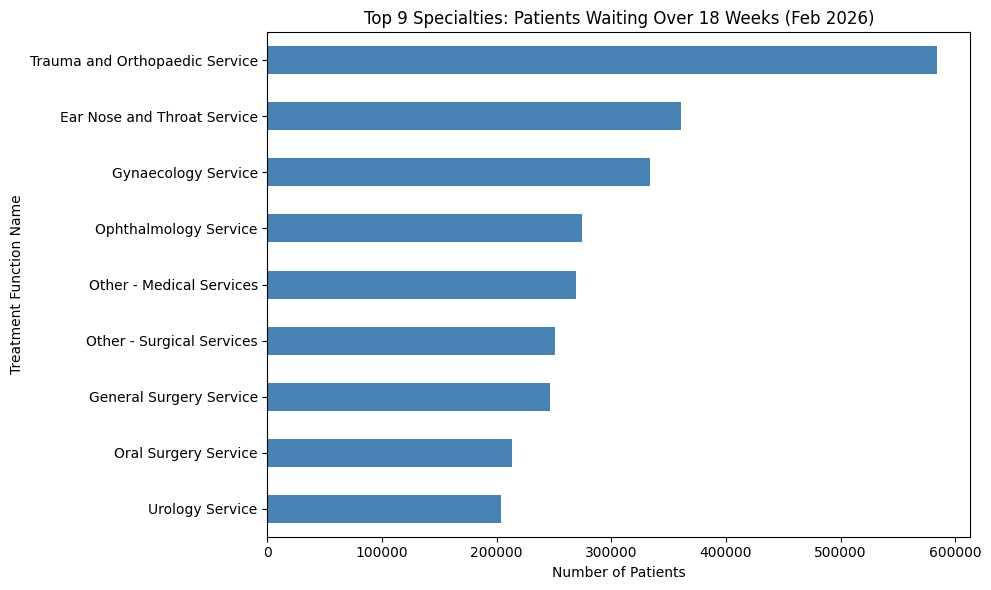

Chart saved to docs folder


In [6]:
import matplotlib.pyplot as plt

# Remove the Total row
specialty_data = over_18_by_specialty[over_18_by_specialty.index != 'Total']

# Plot
plt.figure(figsize=(10, 6))
specialty_data.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 9 Specialties: Patients Waiting Over 18 Weeks (Feb 2026)')
plt.xlabel('Number of Patients')
plt.tight_layout()
plt.savefig('docs/over_18_weeks_by_specialty.png')
plt.show()

print("Chart saved to docs folder")

In [7]:
org_total = df["Provider Org Name"]
print(org_total.nunique())

514
